Number of entities in the statement file: 15000
Total number of distinct properties: 1619


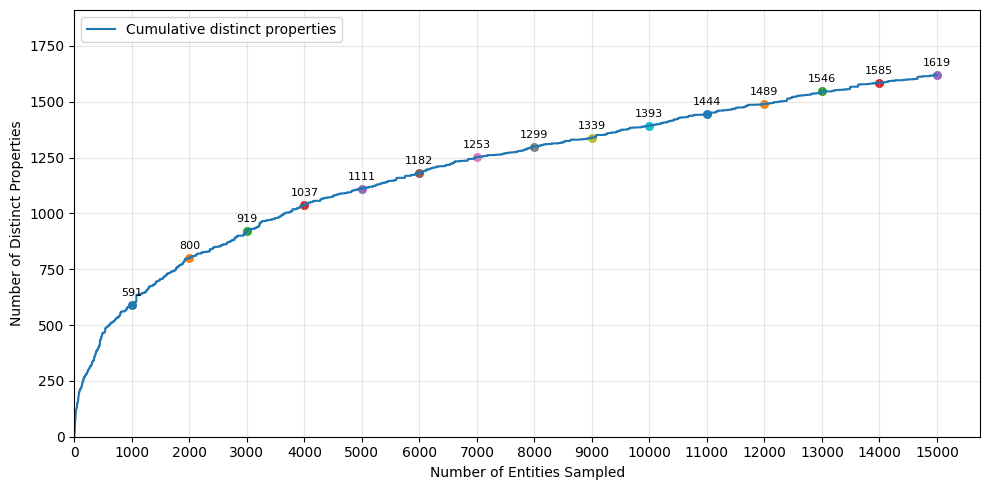

Property discovery curve saved to 15000business_property_discovery_curve.png


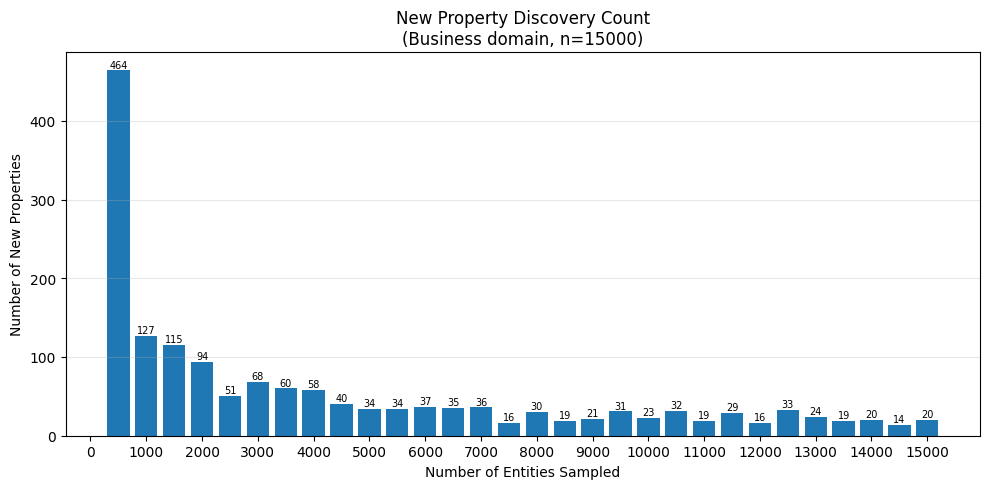

New property count figure saved to 15000business_new_property_count.png
Summary table saved to 15000business_property_saturation_summary.xlsx


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("15000business_statements.xlsx")
df = df[["QID", "Property_ID"]].dropna()
df = df.drop_duplicates(subset=["QID", "Property_ID"])

qid_order = df["QID"].drop_duplicates().tolist()

entity_properties = df.groupby("QID")["Property_ID"].apply(set).to_dict()

N = len(qid_order)

print(f"Number of entities in the statement file: {N}")


# Calculate cumulative property discovery
cumulative_properties = set()
cumulative_counts = []

for qid in qid_order:
    cumulative_properties.update(entity_properties.get(qid, set()))
    cumulative_counts.append(len(cumulative_properties))

total_properties = cumulative_counts[-1]

print(f"Total number of distinct properties: {total_properties}")



window = 500
previous_count = 0
summary_rows = []

for n in range(window, N + 1, window):
    current_count = cumulative_counts[n - 1]
    new_count = current_count - previous_count
    coverage = current_count / total_properties * 100

    summary_rows.append({
        "Number_of_Entities": n,
        "Cumulative_Properties": current_count,
        "Coverage_Percentage": coverage,
        "New_Properties": new_count
    })

    previous_count = current_count

# If the number of entities is not exactly divisible by 500
if N % window != 0:
    current_count = cumulative_counts[-1]
    new_count = current_count - previous_count
    coverage = current_count / total_properties * 100

    summary_rows.append({
        "Number_of_Entities": N,
        "Cumulative_Properties": current_count,
        "Coverage_Percentage": coverage,
        "New_Properties": new_count
    })


summary_df = pd.DataFrame(summary_rows)
summary_file = "15000business_property_saturation_summary.xlsx"
summary_df.to_excel(summary_file, index=False)


increment_x = []
increment_y = []

previous_count = 0

for n in range(window, N + 1, window):
    current_count = cumulative_counts[n - 1]
    increment_x.append(n)
    increment_y.append(current_count - previous_count)
    previous_count = current_count

if N % window != 0:
    current_count = cumulative_counts[-1]
    increment_x.append(N)
    increment_y.append(current_count - previous_count)


# Cumulative property discovery curve
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, N + 1),
    cumulative_counts,
    linewidth=1.5,
    label="Cumulative distinct properties"
)

#plt.axhline(
#    y=total_properties,
#    linestyle="--",
#    linewidth=1,
#    alpha=0.6,
#    label=f"Total: {total_properties} properties"
#)

milestones = [1000, 2000, 3000, 4000, 5000,6000, 7000, 8000, 9000, 10000,11000, 12000, 13000, 14000, N]

for n in milestones:
    if n <= N:
        value = cumulative_counts[n - 1]
        plt.scatter(n, value, s=30)
        plt.annotate(
            str(value),
            xy=(n, value),
            xytext=(n, value + total_properties * 0.025),
            fontsize=8,
            ha="center"
        )

plt.xlabel("Number of Entities Sampled")
plt.ylabel("Number of Distinct Properties")
plt.title(f"")
plt.legend(
    loc="upper left",
    frameon=True
)
plt.grid(True, alpha=0.3)
plt.xlim(0, N * 1.05)
plt.ylim(0, total_properties * 1.18)
plt.xticks(range(0, N + 1000, 1000))

plt.tight_layout()

curve_file = "15000business_property_discovery_curve.png"
plt.savefig(curve_file, dpi=150, bbox_inches="tight")
plt.show()

print(f"Property discovery curve saved to {curve_file}")

# New property count per 500 entities
plt.figure(figsize=(10, 5))

plt.bar(increment_x, increment_y, width=window * 0.8, align="center")

for x_value, y_value in zip(increment_x, increment_y):
    plt.text(
        x_value,
        y_value + 1,
        str(y_value),
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.xlabel("Number of Entities Sampled")
plt.ylabel("Number of New Properties")
plt.title(f"New Property Discovery Count\n(Business domain, n={N})")
plt.grid(True, alpha=0.3, axis="y")
plt.xticks(range(0, N + 1000, 1000))

plt.tight_layout()

increment_file = "15000business_new_property_count.png"
plt.savefig(increment_file, dpi=150, bbox_inches="tight")
plt.show()

print(f"New property count figure saved to {increment_file}")

print(f"Summary table saved to {summary_file}")